# Quantitative Trading Strategy Analysis

This notebook demonstrates a complete end-to-end analysis of a momentum-based trading strategy using:
- Data ingestion from Yahoo Finance
- Dual Moving Average Crossover strategy with RSI filter
- Vectorized backtesting
- Walk-forward validation
- Performance metrics and visualization

## 1. Setup and Imports

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Import our modules
from src.data_ingestion import fetch_data, fetch_multiple
from src.strategy import DualMAStrategy, MeanReversionStrategy, MomentumStrategy
from src.backtest import Backtester
from src.metrics import calculate_metrics, PerformanceReport, compare_strategies
from src.walk_forward import WalkForwardValidator

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Setup complete!")

Setup complete!


## 2. Data Ingestion

Fetch historical price data from Yahoo Finance.

In [2]:
# Fetch data for analysis
ticker = 'AAPL'
start_date = '2020-01-01'
end_date = '2024-01-01'

print(f"Fetching data for {ticker}...")
data = fetch_data(ticker, start=start_date, end=end_date)

print(f"\nData shape: {data.shape}")
print(f"Date range: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
print("\nFirst few rows:")
data.head()

INFO:src.data_ingestion:Fetching data for AAPL...


Fetching data for AAPL...


INFO:src.data_ingestion:Successfully fetched 1006 rows for AAPL


INFO:src.data_ingestion:Date range: 2020-01-02 to 2023-12-29



Data shape: (1006, 7)
Date range: 2020-01-02 to 2023-12-29

First few rows:


,Open,High,Low,Close,Volume,Dividends,Stock_Splits
Date,,,,,,,
2020-01-02,71.282568,72.331694,71.029915,72.271538,135480400,0.0,0.0
2020-01-03,71.501549,72.326889,71.345145,71.568924,146322800,0.0,0.0
2020-01-06,70.693036,72.177684,70.442784,72.139183,118387200,0.0,0.0
2020-01-07,72.148828,72.403889,71.580958,71.799927,108872000,0.0,0.0
2020-01-08,71.503960,73.255706,71.503960,72.954926,132079200,0.0,0.0


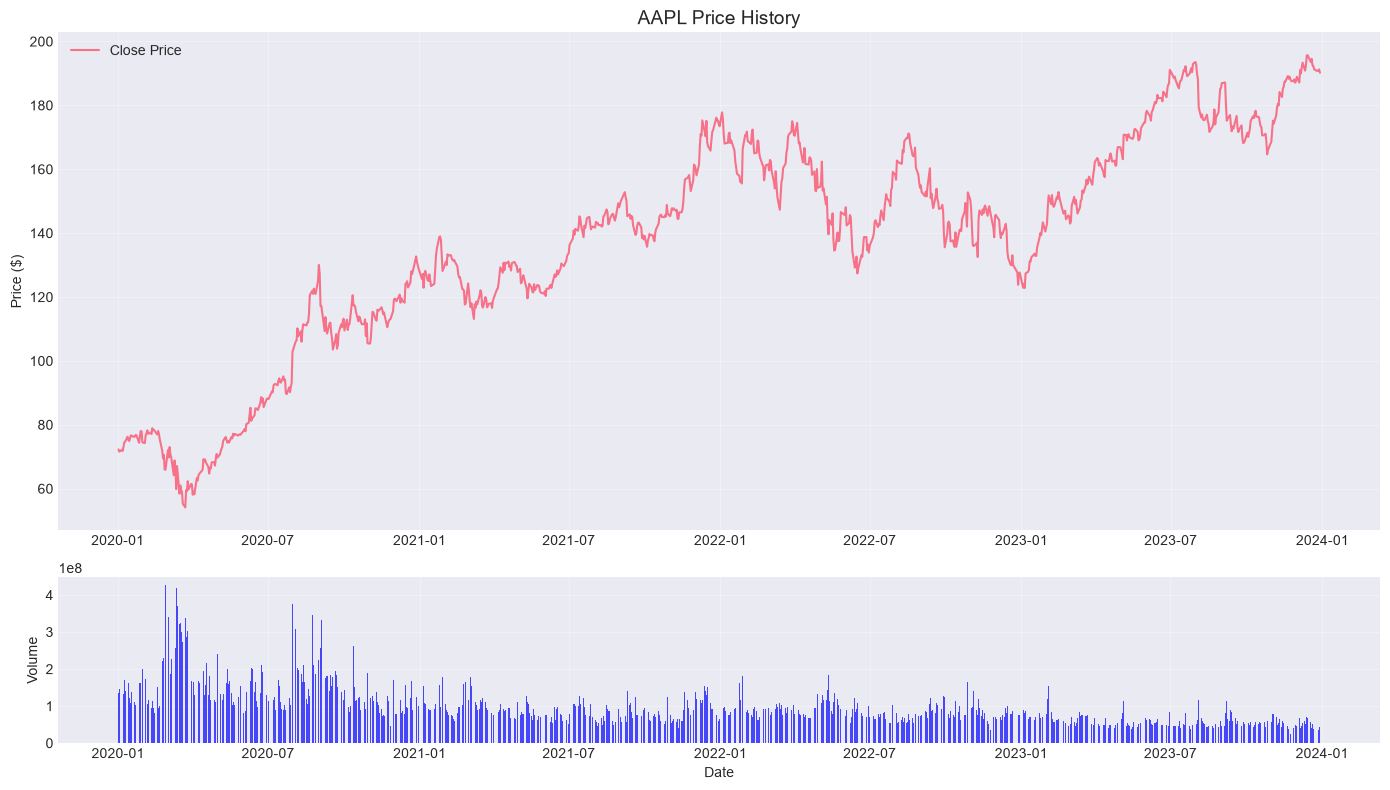

In [3]:
# Visualize price data
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Price chart
axes[0].plot(data.index, data['Close'], label='Close Price', linewidth=1.5)
axes[0].set_title(f'{ticker} Price History', fontsize=14)
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volume chart
axes[1].bar(data.index, data['Volume'], alpha=0.7, color='blue')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Strategy Implementation

We'll implement and test a **Dual Moving Average Crossover with RSI Filter** strategy.

### Strategy Logic:
- **Entry**: Fast MA crosses above Slow MA AND RSI > 50 (momentum confirmation)
- **Exit**: Fast MA crosses below Slow MA OR RSI > 70 (overbought)
- **Position Sizing**: Volatility-based (ATR)

In [4]:
# Initialize strategy
strategy = DualMAStrategy(
    fast_window=20,
    slow_window=50,
    rsi_period=14,
    rsi_overbought=70,
    position_size=0.1
)

# Generate signals
signals = strategy.generate_signals(data)

print("Signal Summary:")
print(f"  Total signals: {(signals['signal'] != 0).sum()}")
print(f"  Buy signals: {(signals['signal'] == 1).sum()}")
print(f"  Sell signals: {(signals['signal'] == -1).sum()}")

signals[['Close', 'fast_ma', 'slow_ma', 'rsi', 'signal', 'position']].tail(20)

INFO:src.strategy:Generated 20 signals


INFO:src.strategy:Total long entries: 10


INFO:src.strategy:Total exits: 10


Signal Summary:
  Total signals: 21
  Buy signals: 10
  Sell signals: 10


,Close,fast_ma,slow_ma,rsi,signal,position
Date,,,,,,
2023-12-01,188.936569,184.845535,177.130726,66.351337,0.0,0
2023-12-04,187.148346,185.488319,177.424543,65.422893,0.0,0
2023-12-05,191.090332,186.200922,177.771744,68.276180,0.0,0
2023-12-06,190.003586,186.731416,178.178511,62.759080,0.0,0
2023-12-07,191.930084,187.305450,178.653998,63.302141,0.0,0
2023-12-08,193.352737,187.974297,179.152809,66.217583,0.0,0
2023-12-11,190.853195,188.309215,179.591367,54.474852,0.0,0
2023-12-12,192.364777,188.798747,180.010035,60.149563,0.0,0
2023-12-13,195.575623,189.318411,180.519560,64.692795,0.0,0


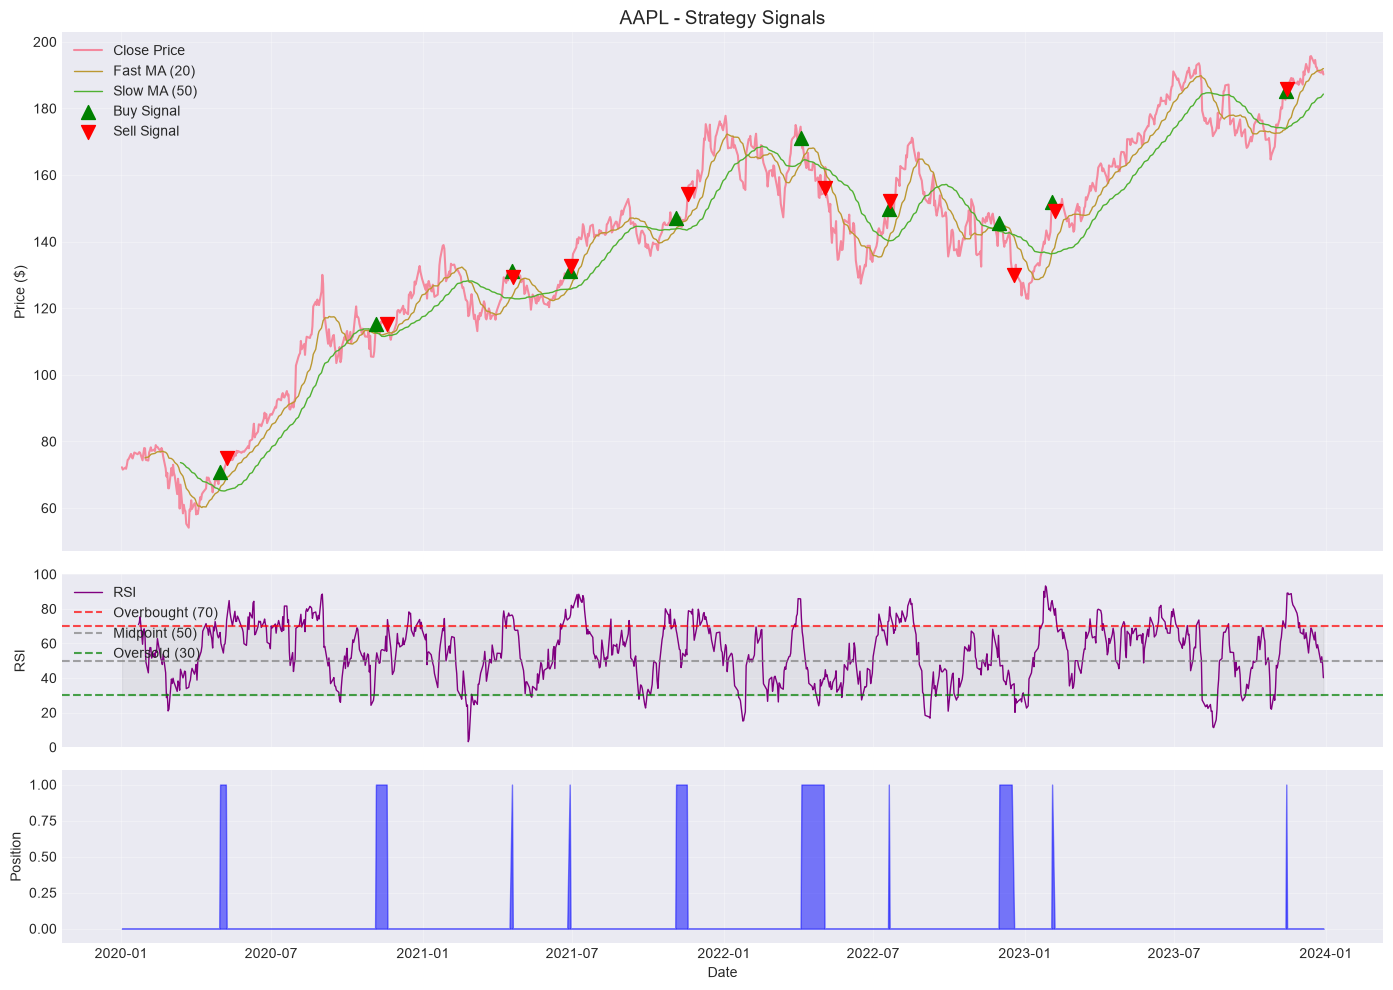

In [5]:
# Visualize strategy signals
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, 
                        gridspec_kw={'height_ratios': [3, 1, 1]})

# Plot 1: Price with moving averages and signals
ax1 = axes[0]
ax1.plot(signals.index, signals['Close'], label='Close Price', linewidth=1.5, alpha=0.8)
ax1.plot(signals.index, signals['fast_ma'], label=f'Fast MA ({strategy.fast_window})', linewidth=1)
ax1.plot(signals.index, signals['slow_ma'], label=f'Slow MA ({strategy.slow_window})', linewidth=1)

# Mark buy/sell signals
buy_signals = signals[signals['signal'] == 1]
sell_signals = signals[signals['signal'] == -1]

ax1.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', 
           s=100, label='Buy Signal', zorder=5)
ax1.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', 
           s=100, label='Sell Signal', zorder=5)

ax1.set_title(f'{ticker} - Strategy Signals', fontsize=14)
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: RSI
ax2 = axes[1]
ax2.plot(signals.index, signals['rsi'], label='RSI', color='purple', linewidth=1)
ax2.axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought (70)')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='Midpoint (50)')
ax2.axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold (30)')
ax2.fill_between(signals.index, 30, 70, alpha=0.1, color='gray')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Plot 3: Position
ax3 = axes[2]
ax3.fill_between(signals.index, signals['position'], alpha=0.5, color='blue')
ax3.set_ylabel('Position')
ax3.set_xlabel('Date')
ax3.set_ylim(-0.1, 1.1)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Backtesting

Run the backtest and analyze performance.

In [6]:
# Run backtest
backtest = Backtester(
    data=data,
    strategy=strategy,
    initial_capital=100000,
    commission=0.001,  # 0.1% commission
    slippage=0.0005,   # 0.05% slippage
)

results = backtest.run()

print("Backtest Complete!\n")
print(f"Final Equity: ${results['metrics']['final_equity']:,.2f}")
print(f"Total Return: {results['metrics']['total_return_pct']:.2f}%")
print(f"Number of Trades: {results['metrics']['num_trades']}")

INFO:src.backtest:Starting backtest with DualMA_Strategy


INFO:src.backtest:Initial capital: $100,000.00


INFO:src.strategy:Generated 20 signals


INFO:src.strategy:Total long entries: 10


INFO:src.strategy:Total exits: 10


INFO:src.backtest:Backtest complete. Final equity: $98,767.24


INFO:src.backtest:Total return: -1.23%


Backtest Complete!

Final Equity: $98,767.24
Total Return: -1.23%
Number of Trades: 10


In [7]:
# Display detailed metrics
metrics = results['metrics']

print("=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)
print(f"\nReturns:")
print(f"  Total Return:        {metrics['total_return_pct']:>10.2f}%")
print(f"  Annualized Return:   {metrics['annualized_return_pct']:>10.2f}%")
print(f"  Volatility:          {metrics['volatility_pct']:>10.2f}%")

print(f"\nRisk Metrics:")
print(f"  Sharpe Ratio:        {metrics['sharpe_ratio']:>10.2f}")
print(f"  Sortino Ratio:       {metrics['sortino_ratio']:>10.2f}")
print(f"  Max Drawdown:        {metrics['max_drawdown_pct']:>10.2f}%")
print(f"  Calmar Ratio:        {metrics['calmar_ratio']:>10.2f}")

print(f"\nTrade Statistics:")
print(f"  Total Trades:        {metrics['num_trades']:>10}")
print(f"  Win Rate:            {metrics['win_rate_pct']:>10.1f}%")
print(f"  Avg Win:             ${metrics['avg_win']:>10.2f}")
print(f"  Avg Loss:            ${metrics['avg_loss']:>10.2f}")
print(f"  Profit Factor:       {metrics['profit_factor']:>10.2f}")
print(f"  Avg Trade Duration:  {metrics['avg_trade_duration_days']:>10.1f} days")
print("=" * 60)

PERFORMANCE METRICS

Returns:
  Total Return:             -1.23%
  Annualized Return:        -0.31%
  Volatility:                0.65%

Risk Metrics:
  Sharpe Ratio:             -3.55
  Sortino Ratio:            -1.27
  Max Drawdown:             -2.11%
  Calmar Ratio:             -0.15

Trade Statistics:
  Total Trades:                10
  Win Rate:                  50.0%
  Avg Win:             $    250.35
  Avg Loss:            $   -476.89
  Profit Factor:             0.52
  Avg Trade Duration:         8.9 days


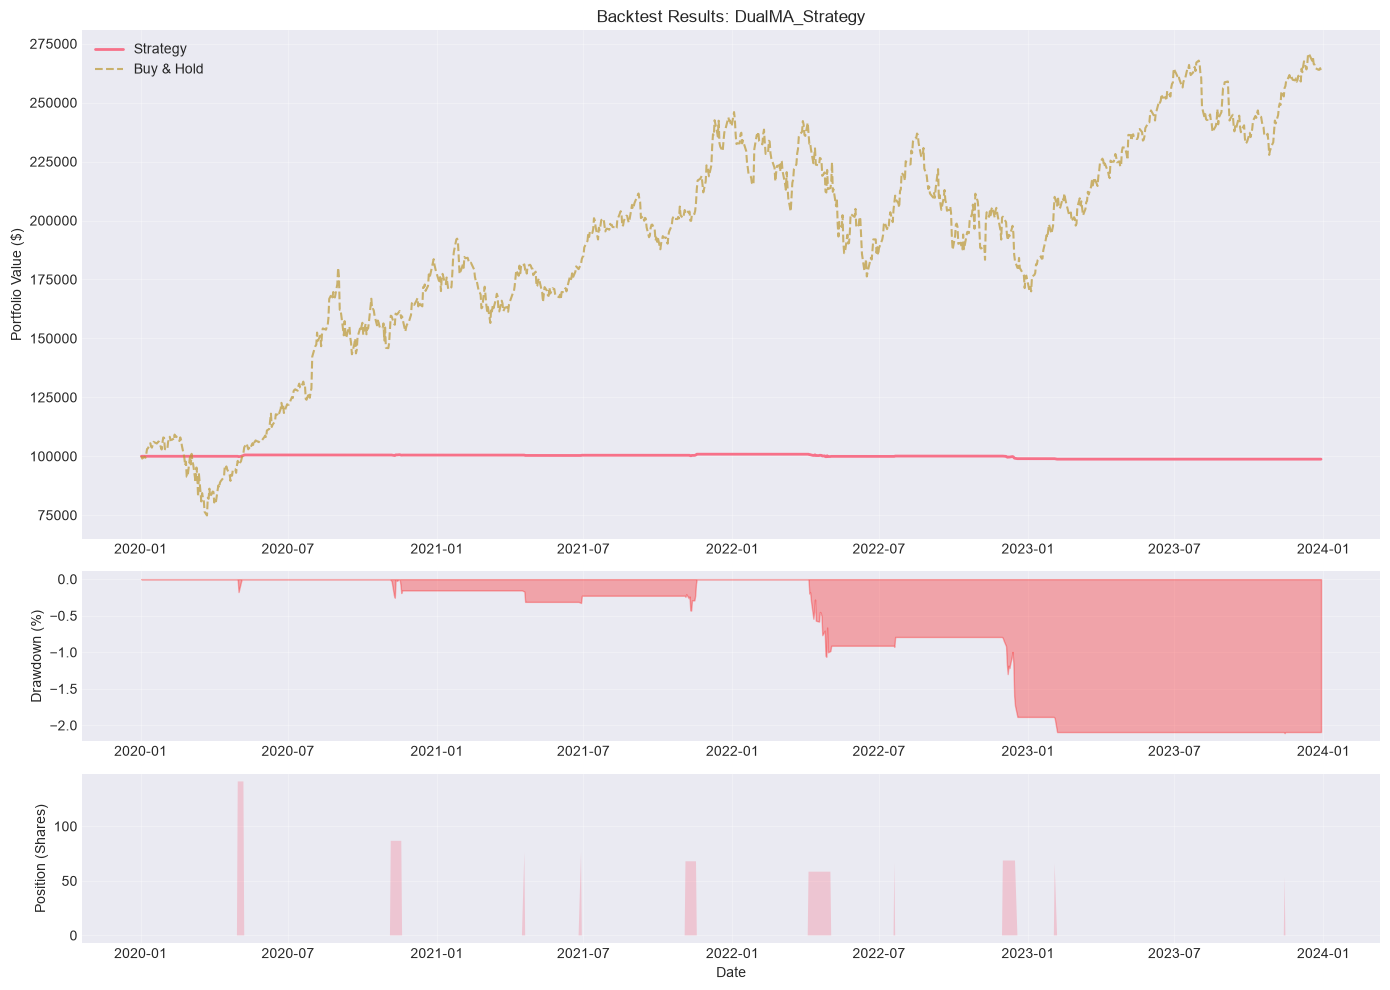

In [8]:
# Plot backtest results
fig = backtest.plot_results(figsize=(14, 10))
plt.show()

In [9]:
# Trade log
trade_log = backtest.get_trade_log()
if not trade_log.empty:
    print(f"\nTrade Log ({len(trade_log)} trades):")
    print(trade_log.to_string())
else:
    print("No trades were executed.")


Trade Log (10 trades):
  entry_date  exit_date  entry_price  exit_price      shares          pnl  return_pct  duration_days
0 2020-04-30 2020-05-08    70.898667   74.966946  141.116898   563.523758    5.632421              8
1 2020-11-05 2020-11-19   115.414139  115.119291   86.687819   -35.539115   -0.355214             14
2 2021-04-19 2021-04-20   131.165129  129.352878   76.277896  -148.101394   -1.480274              1
3 2021-06-28 2021-06-29   131.329472  132.707036   76.182443    94.836236    0.947888              1
4 2021-11-04 2021-11-18   147.315656  154.129455   67.915388   452.294046    4.520680             14
5 2022-04-05 2022-05-03   171.301153  155.899703   58.405911  -908.641226   -9.081871             28
6 2022-07-20 2022-07-21   149.973967  152.085525   66.711578   130.719514    1.306542              1
7 2022-12-01 2022-12-19   145.782053  129.983697   68.629847 -1093.159496  -10.926132             18
8 2023-02-03 2023-02-06   151.866529  148.994679   65.880218  -199.

## 5. Walk-Forward Validation

Validate strategy robustness using walk-forward analysis.

In [10]:
# Run walk-forward validation
print("Running Walk-Forward Validation...\n")

validator = WalkForwardValidator(
    data=data,
    strategy_class=DualMAStrategy,
    strategy_params={'fast_window': 20, 'slow_window': 50},
    n_splits=5,
)

wf_results = validator.run()
validator.print_summary()

INFO:src.walk_forward:Starting walk-forward validation with 5 splits


INFO:src.walk_forward:
--- Fold 1/5 ---


INFO:src.walk_forward:Train: 2020-01-02 00:00:00 to 2020-09-03 00:00:00 (171 bars)


INFO:src.walk_forward:Test: 2020-09-04 00:00:00 to 2021-05-05 00:00:00 (167 bars)


INFO:src.backtest:Starting backtest with DualMA_Strategy


...

INFO:src.backtest:Total return: 0.00%


INFO:src.walk_forward:


INFO:src.walk_forward:WALK-FORWARD VALIDATION COMPLETE


INFO:src.walk_forward:============================================================


Running Walk-Forward Validation...


WALK-FORWARD VALIDATION SUMMARY

FOLD RESULTS:
----------------------------------------------------------------------
 Fold              Test Period  Total Return (%)  Sharpe Ratio  Max Drawdown (%)  Win Rate (%)  Trades
    1 2020-09-04 to 2021-05-05         -0.158106    -12.671427         -0.158106           0.0       1
    2 2021-05-06 to 2021-12-31          0.442289     -2.641727         -0.226169         100.0       1
    3 2022-01-03 to 2022-08-31         -0.797932     -2.989235         -1.071215          50.0       2
    4 2022-09-01 to 2023-05-02         -1.312183     -4.916497         -1.312183           0.0       2
    5 2023-05-03 to 2023-12-29          0.000362    -75.551322         -0.015005         100.0       1

AGGREGATE STATISTICS
                                 Mean      Std        Min         Max
total_return                 -365.114  691.483  -1312.183     442.289
total_return_pct               -0.365    0.691     -1.312       0

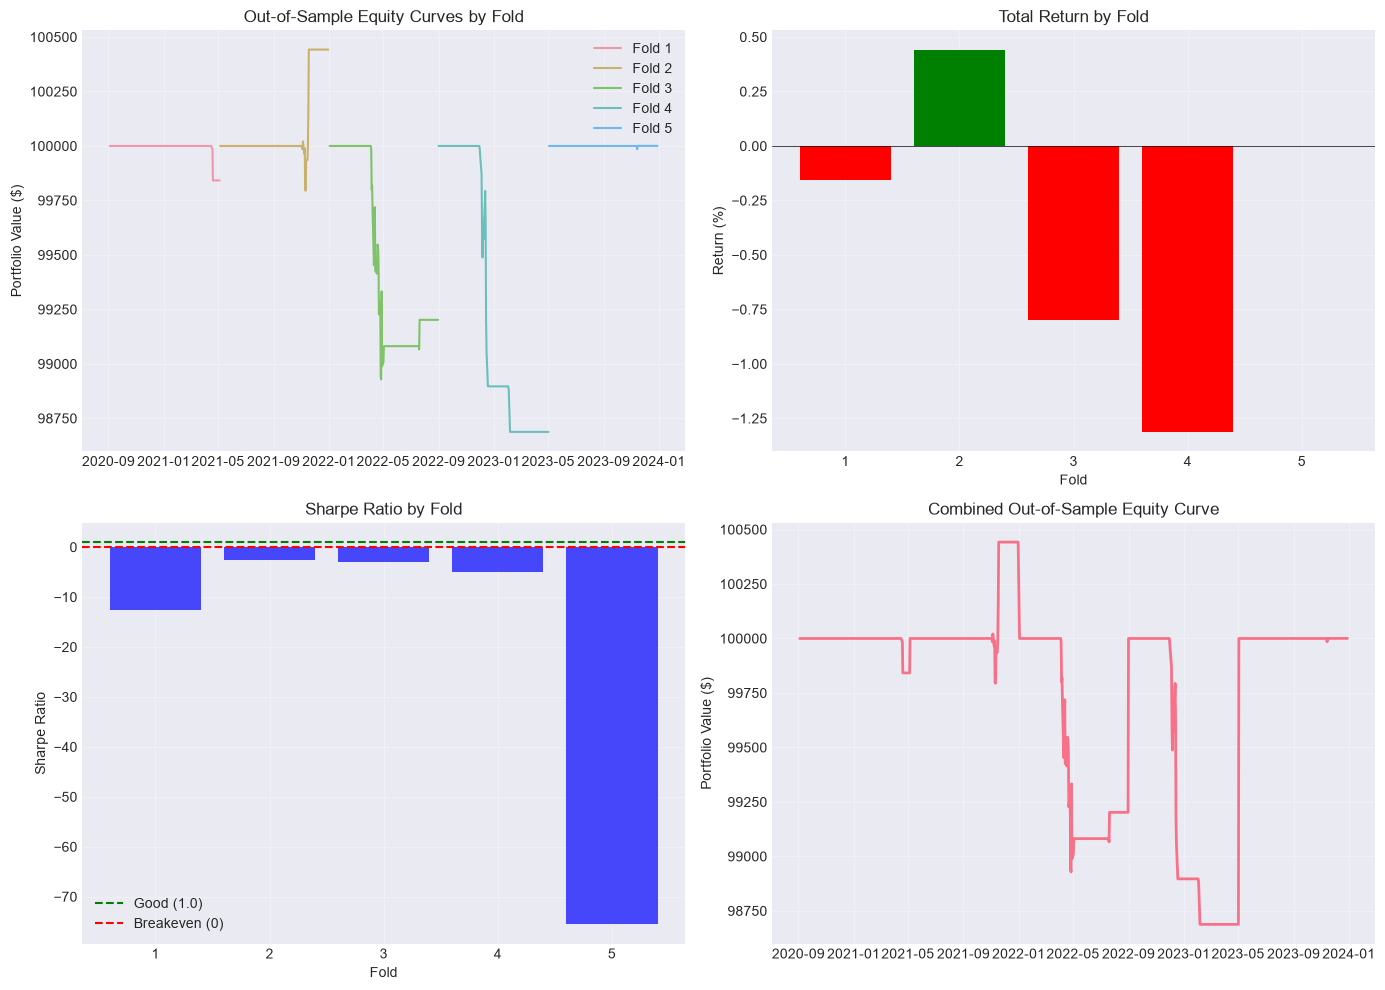

In [11]:
# Plot walk-forward results
fig = validator.plot_results(figsize=(14, 10))
plt.show()

## 6. Strategy Comparison

Compare multiple strategies on the same data.

In [12]:
# Define strategies to compare
strategies = {
    'Dual MA + RSI': DualMAStrategy(fast_window=20, slow_window=50),
    'Mean Reversion (BB)': MeanReversionStrategy(window=20, num_std=2),
    'Momentum (ROC)': MomentumStrategy(roc_period=20, roc_threshold=5),
}

# Run backtests
all_results = {}

for name, strat in strategies.items():
    print(f"Running {name}...")
    bt = Backtester(data, strat, initial_capital=100000)
    all_results[name] = bt.run()

print("\nAll backtests complete!")

INFO:src.backtest:Starting backtest with DualMA_Strategy


INFO:src.backtest:Initial capital: $100,000.00


INFO:src.strategy:Generated 20 signals


INFO:src.strategy:Total long entries: 10


INFO:src.strategy:Total exits: 10


...

INFO:src.backtest:Final position closed at $190.21, P&L: $271.53


Running Dual MA + RSI...
Running Mean Reversion (BB)...
Running Momentum (ROC)...


INFO:src.backtest:Backtest complete. Final equity: $110,387.49


INFO:src.backtest:Total return: 10.39%



All backtests complete!


In [13]:
# Compare strategies
comparison = compare_strategies(all_results)
print("\nStrategy Comparison:")
print(comparison.to_string(index=False))


Strategy Comparison:
           Strategy  Total Return (%)  Ann. Return (%)  Sharpe Ratio  Max DD (%)  Win Rate (%)  Trades  Profit Factor
      Dual MA + RSI         -1.232765        -0.310241     -3.550429   -2.106645     50.000000      10       0.524959
Mean Reversion (BB)          1.136858         0.283574     -0.898060   -2.707053     60.000000      10       1.738371
     Momentum (ROC)         10.387490         2.506474      0.203463   -4.513888     53.333333      15       4.053773


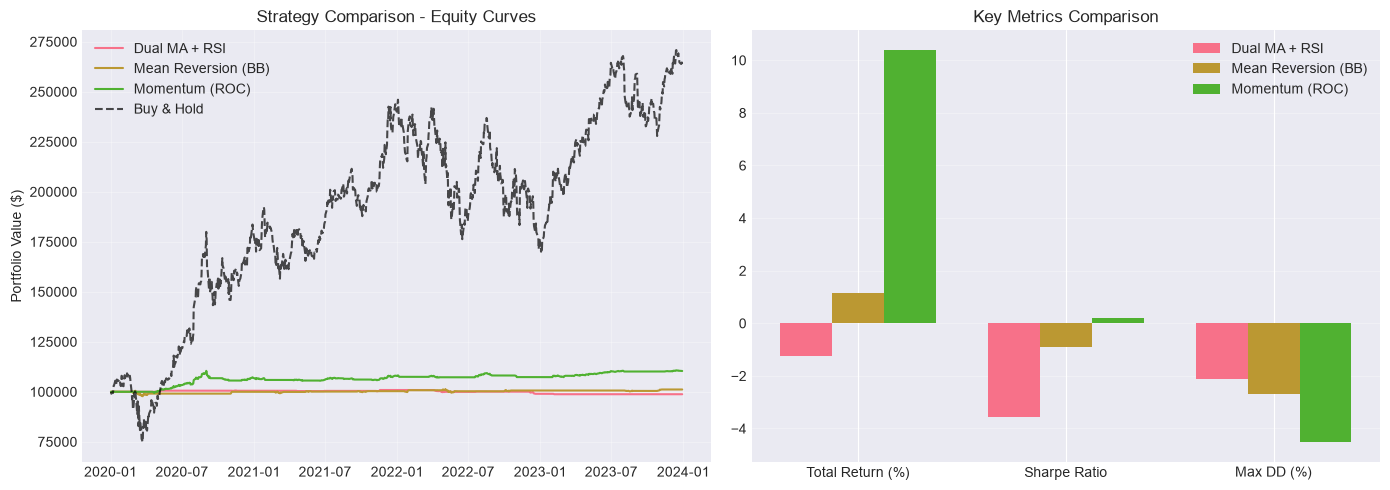

In [14]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Equity curves
ax1 = axes[0]
for name, result in all_results.items():
    equity = result['equity_curve']
    ax1.plot(equity.index, equity, label=name, linewidth=1.5)

# Buy and hold benchmark
bh_returns = data['Close'] / data['Close'].iloc[0]
bh_equity = 100000 * bh_returns
ax1.plot(bh_equity.index, bh_equity, label='Buy & Hold', 
         linestyle='--', alpha=0.7, color='black')

ax1.set_title('Strategy Comparison - Equity Curves')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Metrics comparison
ax2 = axes[1]
metrics_to_plot = ['total_return_pct', 'sharpe_ratio', 'max_drawdown_pct']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (name, result) in enumerate(all_results.items()):
    values = [result['metrics'].get(m, 0) for m in metrics_to_plot]
    ax2.bar(x + i * width, values, width, label=name)

ax2.set_title('Key Metrics Comparison')
ax2.set_xticks(x + width)
ax2.set_xticklabels(['Total Return (%)', 'Sharpe Ratio', 'Max DD (%)'])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Risk Analysis

Analyze risk characteristics of the strategy.

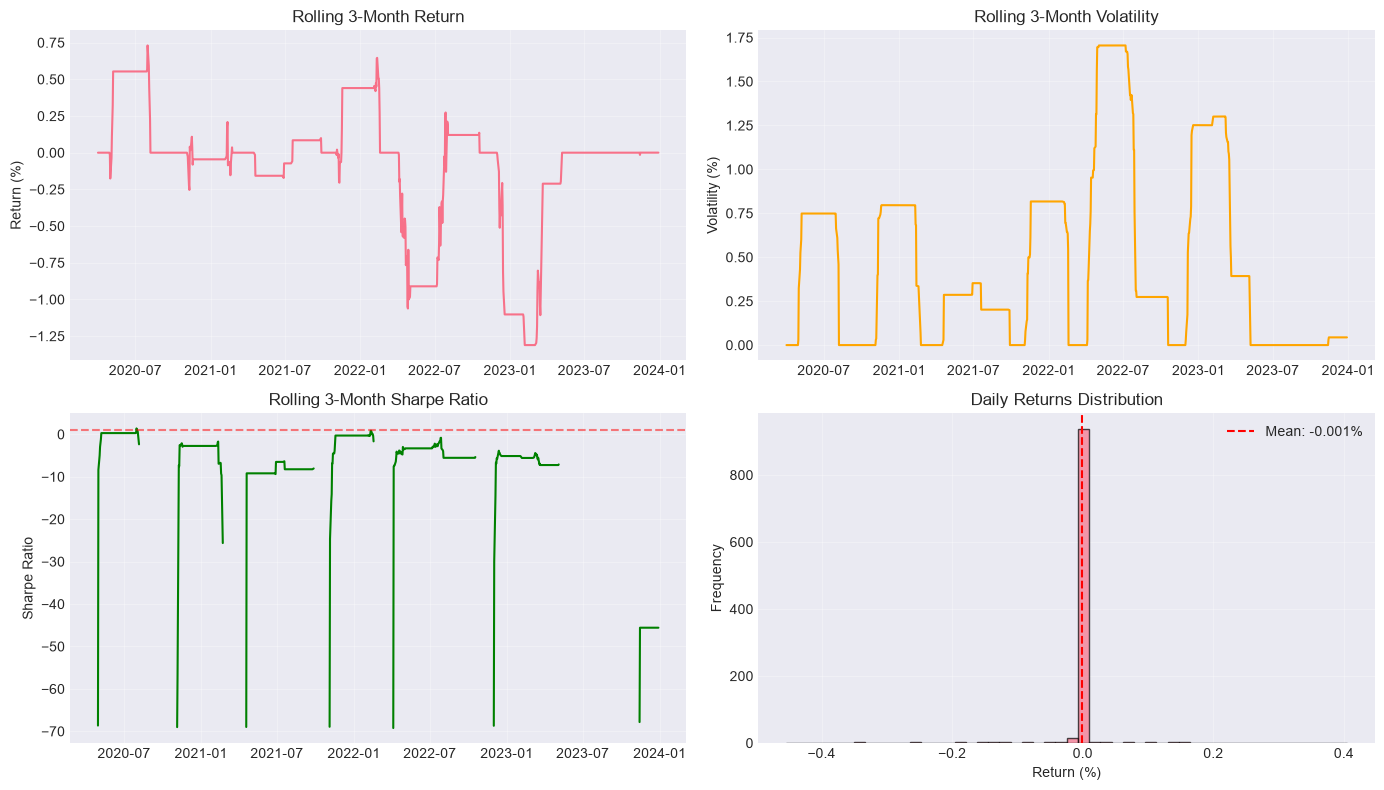

In [15]:
# Get strategy returns
strategy_returns = results['returns']

# Calculate rolling metrics
from src.metrics import calculate_rolling_metrics

rolling = calculate_rolling_metrics(strategy_returns, window=63)

# Plot rolling metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Rolling return
axes[0, 0].plot(rolling.index, rolling['return'] * 100)
axes[0, 0].set_title('Rolling 3-Month Return')
axes[0, 0].set_ylabel('Return (%)')
axes[0, 0].grid(True, alpha=0.3)

# Rolling volatility
axes[0, 1].plot(rolling.index, rolling['volatility'] * 100, color='orange')
axes[0, 1].set_title('Rolling 3-Month Volatility')
axes[0, 1].set_ylabel('Volatility (%)')
axes[0, 1].grid(True, alpha=0.3)

# Rolling Sharpe
axes[1, 0].plot(rolling.index, rolling['sharpe'], color='green')
axes[1, 0].axhline(y=1, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Rolling 3-Month Sharpe Ratio')
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].grid(True, alpha=0.3)

# Return distribution
axes[1, 1].hist(strategy_returns * 100, bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].axvline(strategy_returns.mean() * 100, color='red', linestyle='--', 
                   label=f'Mean: {strategy_returns.mean()*100:.3f}%')
axes[1, 1].set_title('Daily Returns Distribution')
axes[1, 1].set_xlabel('Return (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Calculate drawdown periods
from src.metrics import calculate_drawdown_series

drawdowns = calculate_drawdown_series(results['equity_curve'])

print("Drawdown Periods:")
print(drawdowns.to_string())

if not drawdowns.empty:
    print(f"\nWorst Drawdown: {drawdowns['max_drawdown'].min()*100:.2f}%")
    print(f"Longest Duration: {drawdowns['duration_days'].max()} days")

Drawdown Periods:
       start        end  max_drawdown  duration_days
0 2020-04-30 2020-05-04     -0.001760              4
1 2020-11-05 2020-11-10     -0.002539              5
2 2020-11-12 2020-11-13     -0.000234              1
3 2020-11-17 2021-11-17     -0.004305            365
4 2022-04-05 2023-12-29     -0.021066            633

Worst Drawdown: -2.11%
Longest Duration: 633 days


## 8. Conclusions

### Summary

This notebook demonstrated:
1. **Data Ingestion**: Fetching clean historical data from Yahoo Finance
2. **Strategy Development**: Implementing a momentum-based trading strategy
3. **Backtesting**: Vectorized backtesting with realistic costs
4. **Walk-Forward Validation**: Demonstrating strategy robustness
5. **Risk Analysis**: Comprehensive performance and risk metrics

### Key Findings (AAPL, 2020-01-01 to 2024-01-01, real run output above)

- The Dual MA + RSI strategy showed **negative** performance on the test data:
  -1.23% total return vs. buy-and-hold, over 10 trades, 50% win rate,
  profit factor 0.52 (losses outweigh wins).
- Walk-forward validation indicated **overfit / not robust** behavior: each of
  the 5 folds only generated 1-2 trades, returns swing from -1.31% to +0.44%
  fold to fold with no consistent sign, and Sharpe ratios are wildly unstable
  (-75.6 to -2.6) purely because so few trades land in each window — there
  isn't enough trade volume for these per-fold metrics to be meaningful, which
  is itself the finding: this strategy/ticker/window combination doesn't
  generate enough signal to validate robustly.
- Risk-adjusted returns (Sharpe ratio) were **below 1.0** — in fact negative
  (-3.55) for the full-period backtest.
- In the strategy comparison, **Momentum (ROC)** was the only one of the three
  to post a positive Sharpe ratio (0.20) and the strongest return (+10.4%) on
  this ticker/window, while Dual MA + RSI was the weakest performer.

### Limitations

- Past performance does not guarantee future results
- Transaction costs and slippage estimates may vary
- Strategy may perform differently in different market regimes
- Single-ticker (AAPL), single-window (2020-2024) results — not
  representative of general strategy performance; see the companion
  [R port](https://github.com/Samarty-1/quant-trading-strategy-r) for an
  independent cross-language reproduction of these same numbers

### Next Steps

- Test on multiple assets and time periods
- Add machine learning features
- Implement position sizing optimization
- Paper trade before live deployment
